In [1]:
import warnings
warnings.filterwarnings(action='ignore')

# 워드 자동화

- 워드도 엑셀파일과 마찬가지로 Office Open XML(OOXML) 규약에 맞춰 저장됩니다.

# python-docx

[python-docx](https://python-docx.readthedocs.io/en/latest/)

- openpyxl과 마찬가지로 XML 기반의 워드 문서 형식인 OOXML(Office Open XML)을 활용하여 만들어진 라이브러리입니다.
- 문서 자동화: 수백 장의 계약서, 수료증, 보고서 등 반복적인 문서 작성 작업을 파이썬 코드로 빠르게 처리할 수 있습니다.
- 엑셀 데이터를 다루는 openpyxl이나 pandas와 연계하여, 엑셀의 데이터를 워드 템플릿에 자동으로 채워 넣는 작업이 가능합니다.
- 워드 2007 버전 이후의 표준 형식인 .docx 파일만 편집 가능합니다. (구버전인 .doc은 지원하지 않음)

## python-docx 주요 기능

- 워드 문서(Document) 생성, 수정 및 기존 .docx 파일 불러오기
- 문단(Paragraph) 생성 및 수정, 섹션(Section) 나누기 및 페이지 설정
- 문단 내 글자 마디(Run)별 값 추가 및 수정, 하이퍼링크 생성
- 글꼴 서식(크기, 색상, 굵기), 문단 정렬, 줄 간격 및 스타일 수정
- 표(Table) 생성 및 셀 병합, 이미지(Picture) 삽입 및 크기 조절

## python-docx 설치

In [4]:
!pip install python-docx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -------------------------------------- - 3.9/4.1 MB 28.5 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 15.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [lxml]
   -------------------- ------------------- 1/2 [python-docx]
   ---------------------------------------- 2/2 [python-docx]



## python-docx 관련 핵심 객체별 주요 함수 정리

### 워드 파일의 기본구조

- Document: 워드 파일 전체를 의미합니다.
- Paragraph: 엔터(Enter)로 구분되는 개별 문단입니다.
- Run: 한 문단 내에서 동일한 서식(굵기, 색상 등)이 적용된 최소 글자 단위입니다.
- 
### Document (doc) 관련: 워드 파일 전체 관리
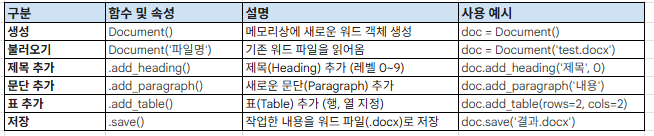

### Paragraph (p) 관련: 문단 및 텍스트 관리
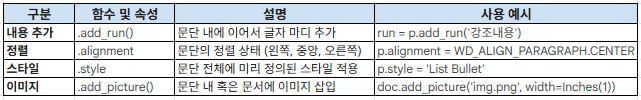

### Run (run) 관련: 글자 세부 서식 관리
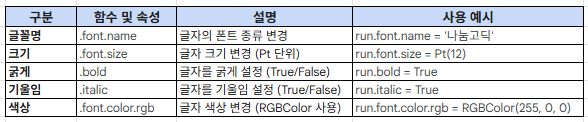


# 워드 파일 생성 및 데이터 입력하기

## 워드 문서 생성하기

- Document(): 메모리상에 새로운 워드 문서 객체를 생성, 하나의 워드 문서
- doc.save('파일명.docx'): 작업한 내용을 워드 파일로 저장

In [5]:
from docx import Document

doc = Document() # 하나의 워드 문서를 생성
doc.save('example.docx')

## 워드 문서 불러오기

 - Document('파일명.docx'): 기존 워드 파일을 불러오기

In [6]:
from docx import Document

# 워드 문서 읽어오기
doc = Document('./data/회의록_템플릿.docx')
doc.save('회의록_20260414.docx')

## 워드 문서 쓰기(1)

<span style="color: blue;"><u>**제목 추가하기**</u></span>

- add_heading('문구', level=0): 제목 추가 (level 0은 Title, 1~9는 Heading 레벨)
- level=0은 문서 전체를 대표하는 '제목(Title)' 스타일로 정의되어 있어 가장 크고 하단 테두리가 포함
- p.alignment = WD_ALIGN_PARAGRAPH.CENTER: 문단을 가운데 정렬 (LEFT, RIGHT, JUSTIFY 가능)

In [7]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()

# 제목 추가
title = doc.add_heading('제목을 이곳에 작성합니다.', level=0) # 0 -> title
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.save('example.docx')

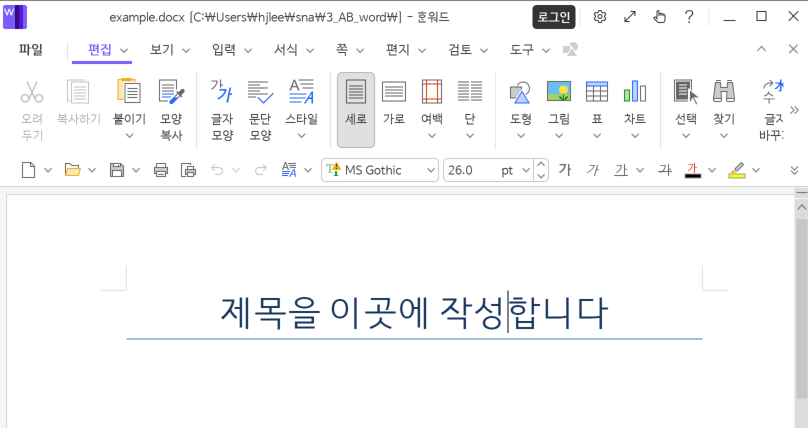

<span style="color: blue;"><u>**제목 레벨별로 추가하기**</u></span>

- 모든 제목 레벨은 워드의 기본 테마에 따라 시각적 구분을 색과 크기, 스타일이 지정됨

In [ ]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()

for i in range(0, 10) :
    title = doc.add_heading('제목울 이곳에 작성합니다.', level=i)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.save('example.docx')

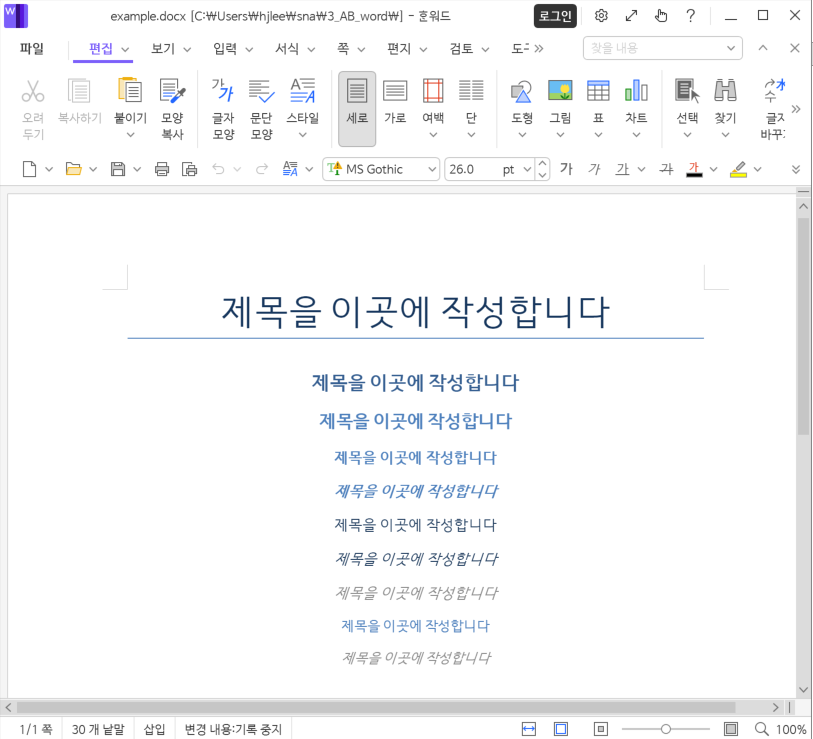

<span style="color: blue;"><u>**단락 추가하기**</u></span>

- 문단(단락)이란 그냥 한줄로 쭉 이어지는 글을 말합니다. 즉, 엔터를 치지 않은 상태의 글을 의미, 제목도 하나의 문단
- doc.add_paragraph('문구'): 새로운 문단 추가
- p.add_run('문구'): 기존 문단 뒤에 문구 추가

In [ ]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn

doc = Document()

# 문서 전체의 기본 폰트를 '맑은 고딕'으로 강제 고정
style = doc.styles['Normal']
style.font.name = 'Malgun Gothic'
style._element.rPr.rFonts.set(qn('w:eastAsia'), 'Malgun Gothic') ## 한글폰트 사용할 때 꼭 지정 !

title = doc.add_heading('제목을 이곳에 입력합니다.', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 단락 추가
p = doc.add_paragraph('첫 번째 단락입니다.')

# 저장
doc.save('example.docx')

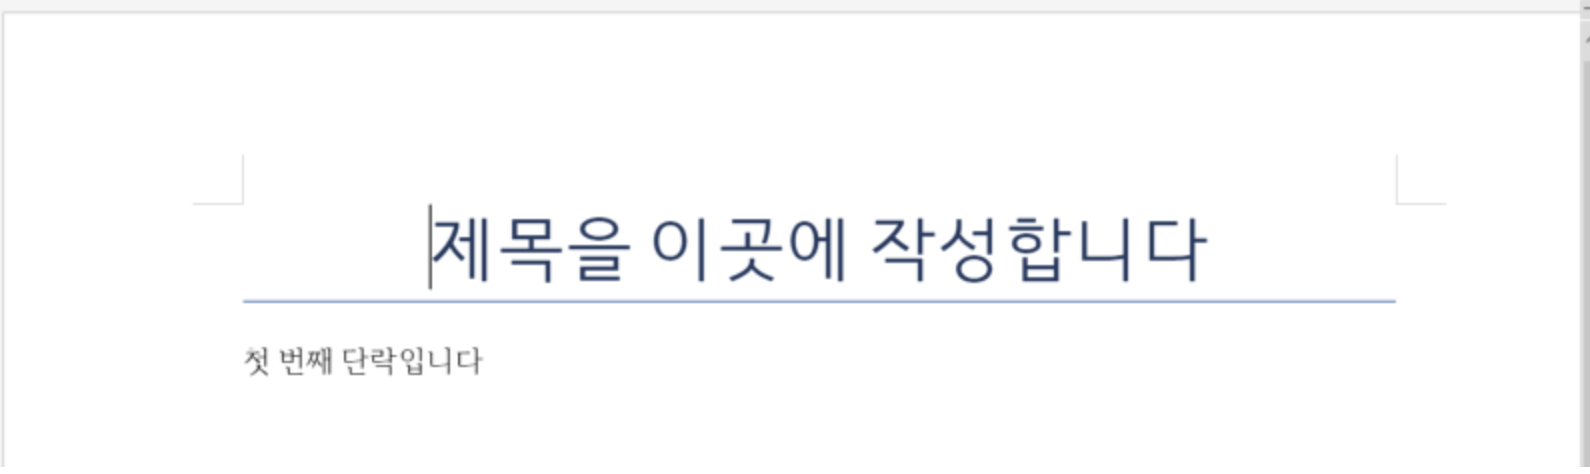

In [ ]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn

doc = Document()

# 문서 전체의 기본 폰트를 '맑은 고딕'으로 강제 고정
style = doc.styles['Normal']
style.font.name = 'Malgun Gothic'
style._element.rPr.rFonts.set(qn('w:eastAsia'), 'Malgun Gothic') ## 한글폰트 사용할 때 꼭 지정 !

title = doc.add_heading('제목을 이곳에 입력합니다.', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 단락 추가
p = doc.add_paragraph('첫 번째 단락입니다.')

# 단락 수정
p.add_run(' 내용을 추가합니다.')

# 저장
doc.save('example.docx')

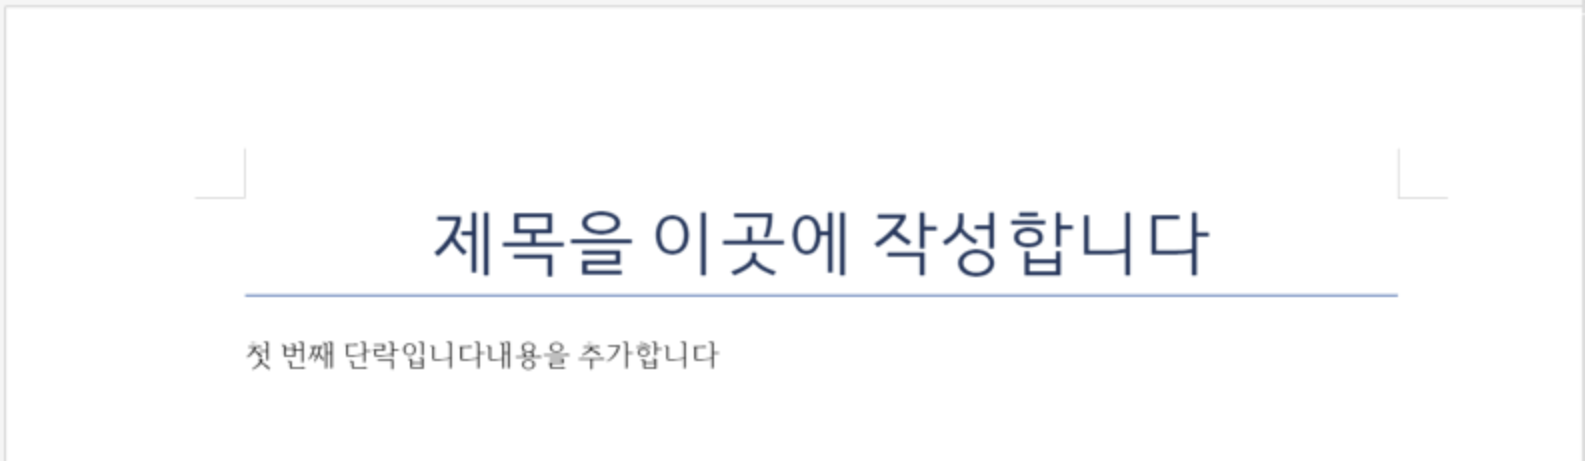

<span style="color: blue;"><u>**단락 끼워넣기**</u></span>

- p.insert_paragraph_before(삽입할 단락): 특정 단락(P) 앞에 단락을 끼워넣기

In [13]:
doc = Document()
title = doc.add_heading('제목을 이곳에 작성합니다.', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

p1 = doc.add_paragraph('첫 단락입니다.')
p2 = doc.add_paragraph('두 단락입니다.')
p3 = doc.add_paragraph('세 단락입니다.')

p1.insert_paragraph_before('첫 번째 단락 앞에 문단을 추가로 입력합니다.')

doc.save('example.docx')

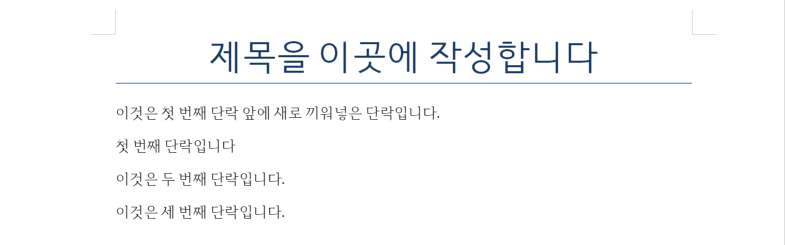

<span style="color: blue;"><u>**단락 수정하기**</u></span>

p.clear(): p 단락 삭제  
p.add_run(): 새로운 내용추가해서 수정

In [14]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()
title = doc.add_heading('제목을 이곳에 작성합니다', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

p = doc.add_paragraph('첫 번째 단락입니다')
p2 = doc.add_paragraph('이것은 두 번째 단락입니다.')
p3 = doc.add_paragraph('이것은 세 번째 단락입니다.')
p.insert_paragraph_before('이것은 첫 번째 단락 앞에 새로 끼워넣은 단락입니다.')

# 두 번째 단락 변경
p2.clear()
p2.add_run('두번째 단락에 텍스트를 변경합니다.')

doc.save('example.docx')

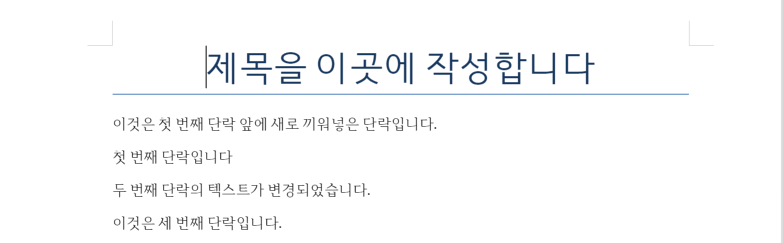

## 워드 문서 쓰기(2)

<span style="color: blue;"><u>**표 추가하기**</u></span>

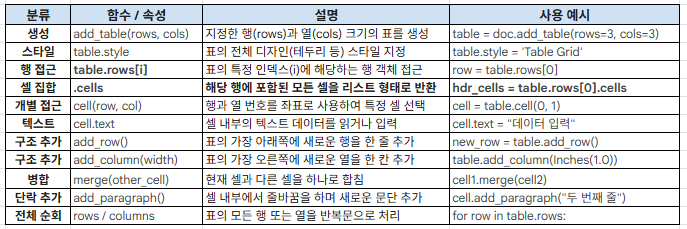


[Table styles in default template](https://python-docx.readthedocs.io/en/latest/user/styles-understanding.html#table-styles-in-default-template)

In [15]:
from docx import Document

doc = Document()

# 3 x 3 크기의 표 추가
table = doc.add_table(rows=3, cols=3)
table.style = 'Table Grid' ## 각 셀에  격자선 추가

# 첫 번째 행에 헤더 값 입력
h_cells = table.rows[0].cells
h_cells[0].text = '헤더1'
h_cells[1].text = '헤더2'
h_cells[2].text = '헤더3'

# for문으로 각 행의 셀에 값 추가
for i in range(1, 3) :
    r_cells = table.rows[i].cells
    r_cells[0].text = f'행 {i}, 열 1'
    r_cells[1].text = f'행 {i}, 열 2'
    r_cells[2].text = f'행 {i}, 열 3'

doc.save('example.docx')

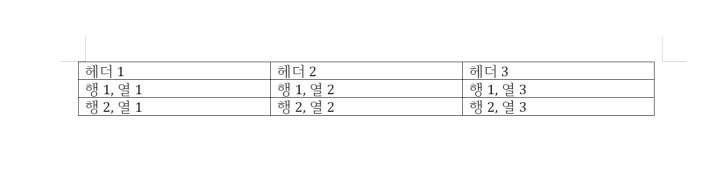

<span style="color: blue;"><u>**목록 추가하기**</u></span>

[Paragraph styles in default template](https://python-docx.readthedocs.io/en/latest/user/styles-understanding.html#paragraph-styles-in-default-template)

In [18]:
from docx import Document

doc = Document()

# 리스트 추가
doc.add_paragraph('첫 번째 항목', style='List Bullet')
doc.add_paragraph('두 번째 항목', style='List Number')
doc.add_paragraph('세 번째 항목', style='List Number')

doc.save('example.docx')

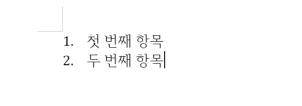

<span style="color: blue;"><u>**이미지 추가하기**</u></span>

- doc.add_picture(이미지경로, width= Inches(m), height=Inches(n)) height 생략가능 width 비례해서 자동 조절

In [19]:
from docx import Document
from docx.shared import Inches

doc = Document()

# 이미지 추가
doc.add_picture('./data/image1.png', width=Inches(1.5))

doc.save('example.docx')

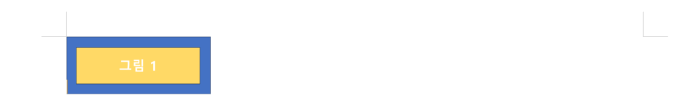

In [20]:
from docx import Document
from docx.shared import Inches

doc = Document()

# 단락 추가하여 텍스트 입력
p = doc.add_paragraph('첫 번째 단락입니다.')

# 단락에 이미지 추가
p.add_run().add_picture('./data/image1.png', width=Inches(1.5))
p.add_run('\n이 텍스트는 이미지 뒤에 추가 되었습니다.')

doc.save('example_image2.docx')

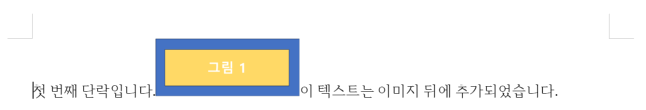

# 워드 파일 서식 설정하기

## 텍스트 서식 설정하기

In [21]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.oxml.ns import qn

doc = Document()
para = doc.add_paragraph()
run = para.add_run('텍스트에 서식을 설정합니다.') # run 객체 생성, 콘텐츠를 담는 일종의 컨테이너

# run 객체에 글자 서식 지정(굵게, 기울임, 밑줄)
run.bold = True
run.italic = True
run.underline =True

# 글꼴 설정
run.font.name = '맑은 고딕'
run._r.rPr.rFonts.set(qn('w:eastAsia'), '맑은 고딕') # 한글 등 동아시아 글꼴 추가 설정 , run._r.rPr.rFonts Run 객체 내부에서 글꼴 정보 접근

# 글자 크기 조정
run.font.size = Pt(12)

# 글자 색상 설정
run.font.color.rgb = RGBColor(0x42, 0x24, 0xE9)

doc.save('example_text_format.docx')



1. w:eastAsia 설정이 왜 필요한가요?   
- Word 문서(docx)의 내부 구조(XML)는 문자 종류에 따라 글꼴을 별도로 관리합니다. 단순히 run.font.name만 설정하면 영문(Latin) 글꼴만 바뀌고, 한글이나 한자 같은 동아시아 언어에는 적용되지 않는 경우가 많습니다.  

- 이유: python-docx 라이브러리의 기본 API는 주로 서구권 기준(ASCII)으로 설계되어 있습니다. 그래서 한글을 '맑은 고딕'으로 바꾸고 싶어도, 프로그램은 "이건 한글이니까 동아시아 글꼴 설정(eastAsia)을 따로 봐줘!"라고 명시하지 않으면 기본 바탕체 등으로 되돌려 버립니다.  

- 작동 원리: run._r.rPr.rFonts.set(qn('w:eastAsia'), '맑은 고딕') 코드는 Word 문서의 실제 XML 데이터에 직접 접근하여 "동아시아 글자(한글)도 '맑은 고딕'을 사용해라"라고 강제로 명령을 내리는 것입니다.  

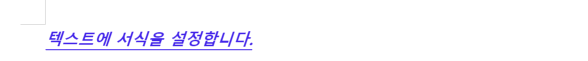

## 단락 서식 설정하기

In [ ]:
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()
para1 = doc.add_paragraph('첫 번째 단락입니다.\n 첫 번째 단락의 두 번째 줄입니다.')
para2 = doc.add_paragraph('두 번째 단락입니다.\n 두 번째 단락의 두 번째 줄입니다.')

# 단락의 텍스트를 중앙으로 정렬
para2.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 단락1의 줄 간격을 12포인트로 설정합니다.
para1.paragraph_format.line_spacing = Pt(12)

# 단락2의 줄 간격을 20포인트로 설정합니다.
para2.paragraph_format.line_spacing = Pt(20)

doc.save('example_para_format.docx')

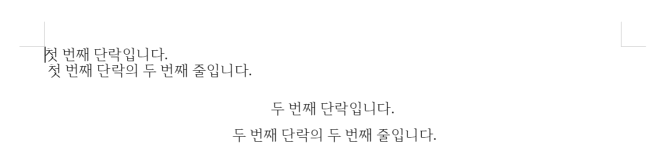

## 머리글과 꼬리글 입력하기

<span style="color: blue;font-size: 20px;"><u>section: </u></span>  
    - 워드 문서의 (논리적)구역을 의미하며, 문서의 레이아웃을 정의하는 단위   
    - 워드 문서는 기본적으로 최소 한개의 섹션(구역)을 가지고 여러 섹션으로 구성할 수도 있음  
    - doc.sections는 문서내의 모든 섹션(구역)을 담고 있는 리스트   
    
    - 관리하는 설정    
        - 머리글과 꼬리글
        - 머리글과 꼬리글 (Headers & Footers): 각 구역만의 고유한 머리글/꼬리글을 가질 수 있음
        - 페이지 방향 (Orientation): 가로(Landscape) 또는 세로(Portrait) 설정.  
        - 페이지 크기 (Page Size): A4, Letter 등 종이 규격 설정.  
        - 여백 (Margins): 상하좌우 및 제본용 여백 설정.  
        - 열 개수 (Columns): 다단 설정 (1단, 2단 등).  

In [23]:
from docx import Document

doc = Document()
para1 = doc.add_paragraph('첫 번째 단락입니다.')

# 머리글 추가
# 문서의 첫 번째 섹션을 가져오고 header(머리글)를 가져와 'header' 변수에 할당
section = doc.sections[0]
header = section.header
p = header.paragraphs[0]
p.text = '머리말 추가 합니다.'

# 꼬리말
footer = section.footer
p1 = footer.paragraphs[0]
p1.text = '꼬리말 추가 합니다.'

doc.save('example_header.docx')


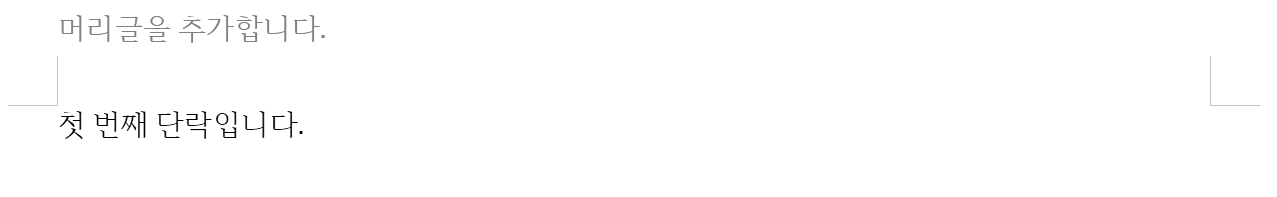

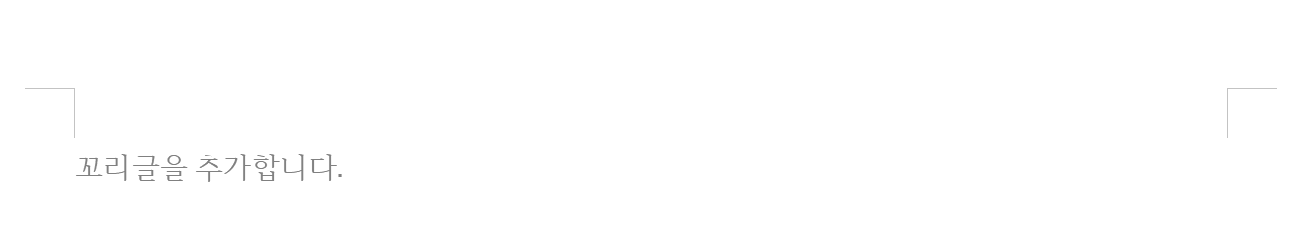

# 워드 파일 읽기

## 단락 읽어 출력하기

- doc.paragraphs: Document 객체의 모든 단락을 포함한 리스트, for문으로 순회하며 text 속성으로 텍스트를 추출
  

In [24]:
from docx import Document

doc = Document('./data/read_doc.docx')

for para in doc.paragraphs :
    print(para.text)

첫 번째 단락의 텍스트에 서식을 설정합니다.
두 번째 단락입니다.
두 번째 단락의 두 번째 줄입니다.


## 단락과 텍스트의 서식 확인하기

- Document(문서) > Paragraph(단락) > Run(런)
- Paragraph (단락): 엔터(Enter)를 쳐서 줄을 바꾸기 전까지의 모든 텍스트 블록
- Run (런): 하나의 단락 안에서 스타일이 바뀌는 지점을 기준으로 나뉘는 조각들
- paragraph.runs: 단락에 포함된 모든 Run 객체들을 담고 있는 리스트

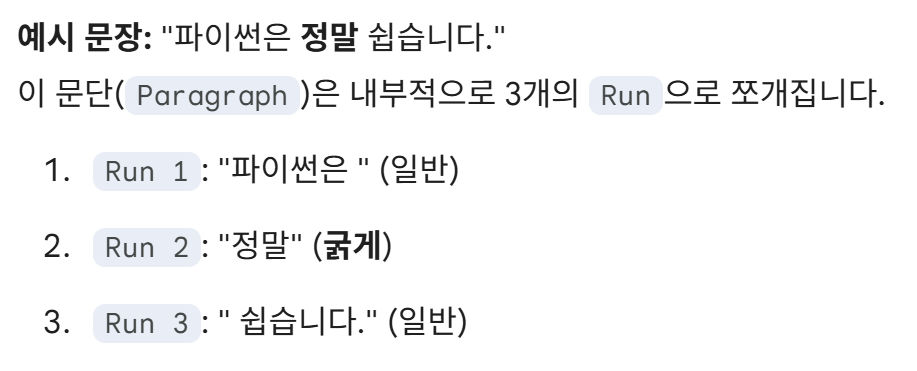

In [27]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document('./data/read_doc.docx')

# 각 단락의 서식을 확인합니다.
for idx, para in enumerate(doc.paragraphs) :
    print(f'단락 번호 {idx}')
    print(f'정렬 : {para.alignment}')

    for run in para.runs :
        print(f'텍스트 내용 : {run.text}')
        print(f'굵게 : {run.bold}')
        print(f'글자 크기 : {run.font.size}')
        print(f'글자 색 : {run.font.color.rgb}')
    print('-' * 20)

단락 번호 0
정렬 : None
텍스트 내용 : 첫 번째 단락의 텍스트에 서식을 설정합니다.
굵게 : True
글자 크기 : 152400
글자 색 : 4224E9
--------------------
단락 번호 1
정렬 : CENTER (1)
텍스트 내용 : 두 번째 단락입니다.
두 번째 단락의 두 번째 줄입니다.
굵게 : None
글자 크기 : None
글자 색 : None
--------------------


## 표 읽어 출력하기

- doc.tables : 문서에 table 정보를 리스트

In [30]:
from docx import Document

doc = Document('./data/read_doc_table.docx')

# 표 읽기
for table in doc.tables :
    for row in table.rows :
        for cell in row.cells :
            print(cell.text, end='')
        print()

헤더 1헤더 2헤더 3
행 1 & 열 1행 1 & 열 2행 1 & 열 3
행 2 & 열 1행 2 & 열 2행 2 & 열 3


## 머리글과 꼬리글 읽기

In [34]:
from docx import Document

# section 은 doc과 paragraph 사이

doc = Document('example_header.docx')

# 머리글 읽기
for section in doc.sections :
    header = section.header

    for para in header.paragraphs :
        print(para.text)

# 꼬리말 읽기
for section in doc.sections :
    footer = section.footer
    
    for para in footer.paragraphs :
        print(para.text)

머리말 추가 합니다.
꼬리말 추가 합니다.


## 이미지 추출하기

<span style="color: blue;"><u>docx2txt</u></span>
- python-docx가 워드 문서를 만들고 수정하는 정교한 도구라면, docx2txt는 이름 그대로 워드(.docx) 파일을 텍스트(.txt)로 단순하게 긁어오는 데 특화된 가벼운 라이브러리
- 복잡한 스타일, 글꼴, 문단 구조 다 무시하고 "그냥 내용(텍스트)만 필요해!"라고 할 때 사용
- 특징: 단순함,이미지 추출 기능, 빠르고 가벼움

- docx2txt.process()는 워드 파일에서 텍스트를 문자열로 추출해 반환하면서, 동시에 문서 내 이미지들을 지정한 경로에 파일로 자동 저장해 주는 함수

In [35]:
!pip install docx2txt

Defaulting to user installation because normal site-packages is not writeable


In [38]:
import docx2txt
import os

# 이미지를 저장할 폴더 경로
save_path = './word_savepath/'

# 폴더가 존재하지 않는 경우 생성
if not os.path.exists(save_path):
    os.makedirs(save_path)

# docx2txt를 사용하여 지정한 문서에서 이미지 추출해서 지정한 경로에 저장, 이미지 이름을 지정하지 못함 image+번호.png 
docx2txt.process('example_image2.docx', save_path)

'첫 번째 단락입니다.\n이 텍스트는 이미지 뒤에 추가 되었습니다.'

# [실습] 송장 파일 자동 생성하기

- 회사에서 제품을 구매한 고객에게 발송하는 송장 템플릿에 고개의 데이터와 구매한 제품, 단가, 합계 금액등의 정보를 넣습니다.
- 필요 파일: 구매고객리스트.xlsx, 송장.docx(템플릿)

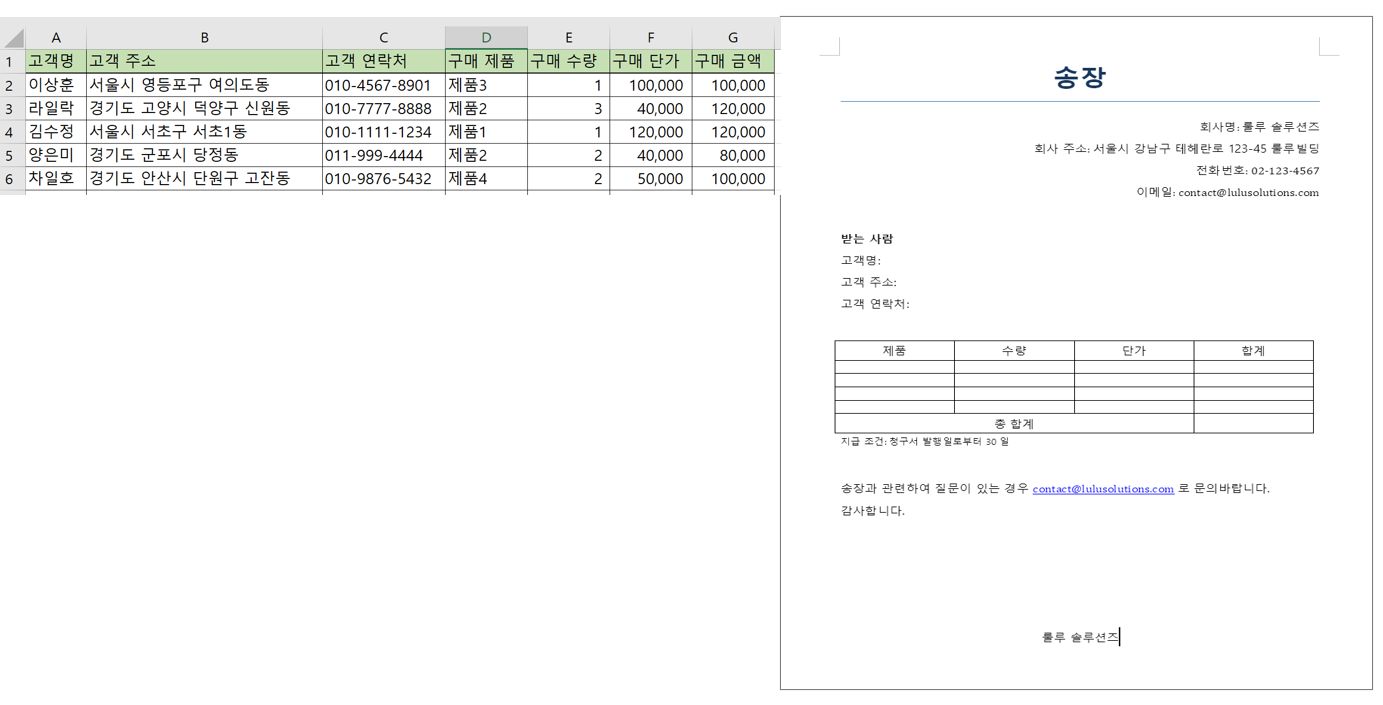

## 구매 데이터를 이용하여 송장 파일 만들기

- 송장 템플릿을 읽어와서 단락과 텍스트의 인덱스, 입력되어 있는 텍스트의 내용을 확인하기

In [46]:
# 기본 송장 템플릿 읽기
from docx import Document
import os

# 워드 파일 열기
doc = Document('./data/송장.docx')

# 단락 읽기 
for idx, para in enumerate(doc.paragraphs) :
    print(f'단락번호 : {idx}')

    for idx, run in enumerate(para.runs) :
        print(f'텍스트 번호 : {idx}')
        print(f'텍스트 내용 : {run.text}')

# 표 확인하기
# 문서에 있는 모든 표를 순회
for t_idx, table in enumerate(doc.tables) :
    print(f'표 : {t_idx}')

    # 표의 행 순회
    for r_idx, row in enumerate(table.rows) :
        print(f'행 : {r_idx}')

        # 행의 셀 순회
        for c_idx, cell in enumerate(row.cells) :
            print(f'셀 : {c_idx} : {cell.text}')
    
    print('-' * 20)
  


단락번호 : 0
텍스트 번호 : 0
텍스트 내용 : 송장
단락번호 : 1
텍스트 번호 : 0
텍스트 내용 : 회사명
텍스트 번호 : 1
텍스트 내용 : : 
텍스트 번호 : 2
텍스트 내용 : 룰루
텍스트 번호 : 3
텍스트 내용 :  
텍스트 번호 : 4
텍스트 내용 : 솔루션즈
텍스트 번호 : 5
텍스트 내용 : 

텍스트 번호 : 6
텍스트 내용 : 회사 주소
텍스트 번호 : 7
텍스트 내용 : : 
텍스트 번호 : 8
텍스트 내용 : 서울시 강남구 테헤란로 
텍스트 번호 : 9
텍스트 내용 : 123-45 
텍스트 번호 : 10
텍스트 내용 : 룰루빌딩
텍스트 번호 : 11
텍스트 내용 :  
텍스트 번호 : 12
텍스트 내용 : 

텍스트 번호 : 13
텍스트 내용 : 전화번호
텍스트 번호 : 14
텍스트 내용 : :
텍스트 번호 : 15
텍스트 내용 :  
텍스트 번호 : 16
텍스트 내용 : 02-123-4567
텍스트 번호 : 17
텍스트 내용 : 

텍스트 번호 : 18
텍스트 내용 : 이메일
텍스트 번호 : 19
텍스트 내용 : :
텍스트 번호 : 20
텍스트 내용 :  
텍스트 번호 : 21
텍스트 내용 : contact@lulusolutions.com
텍스트 번호 : 22
텍스트 내용 : 

단락번호 : 2
텍스트 번호 : 0
텍스트 내용 : 받는 사람
텍스트 번호 : 1
텍스트 내용 : 

텍스트 번호 : 2
텍스트 내용 : 고객명:
텍스트 번호 : 3
텍스트 내용 :  
텍스트 번호 : 4
텍스트 내용 : 

텍스트 번호 : 5
텍스트 내용 : 고객 주소:
텍스트 번호 : 6
텍스트 내용 :  
텍스트 번호 : 7
텍스트 내용 : 

텍스트 번호 : 8
텍스트 내용 : 고객 연락처
텍스트 번호 : 9
텍스트 내용 : :
텍스트 번호 : 10
텍스트 내용 :  
텍스트 번호 : 11
텍스트 내용 : 

단락번호 : 3
텍스트 번호 : 0
텍스트 내용 : 지급 조건
텍스트 번호 : 1
텍스트 내용 : : 
텍스트 번호 : 2
텍스트 내용 

- 인덱스를 활용하여 템플릿에 데이터를 넣어보기

In [ ]:
# 템플릿에 데이터 입력하기
from docx import Document
import os

# 워드 문서 불러오기
doc = Document('./data/송장.docx')

# 고객 정보를 입력해야 하는 단락 지정
target_paragraph = doc.paragraphs[2]

# 각 라벨 뒤에 텍스트 추가
target_paragraph.runs[2].add_text('이호연')
target_paragraph.runs[5].add_text('서울시 마포구 서교동')
target_paragraph.runs[8].add_text('070-333-4444')

# 구매 내역을 입력할 표 지정
table = doc.tables[0]

# 표에 입력할 데이터를 'data' 변수에 리스트로 저장
data = [
 ['제품1', '2', '12,000', '24,000']
]

# 헤더를 제외한 표의 두 번째 행부터 각 셀에 data를 입력
for i, row_data in enumerate(data):
  for j, cell_data in enumerate(row_data):
    table.cell(i+1, j).text = cell_data

# 표의 마지막 행의 마지막 셀에 '총합계'를 입력
table.rows[-1].cells[-1].text = '240,000'

# 생성된 파일을 저장할 '송장폴더'가 존재하지 않는 경우 생성
if not os.path.exists('./송장폴더'):
    os.makedirs('./송장폴더')

# 문서 저장
doc.save('./송장폴더/이호연_송장.docx')

## 여러 파일 한 번에 작성하기

- 구매고객리스트 엑셀파일의 내용을 가지고와서 각 고객에서 보낼 송장을 작성하기

In [54]:
from openpyxl import load_workbook
from docx import Document
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
import os

# 엑셀 파일 불러오기
wb = load_workbook('./data/구매고객리스트.xlsx', data_only = True)
ws = wb.active

# 엑셀 파일의 각 행에 대해 워드 파일 생성
for r_idx, row in enumerate(ws.iter_rows(values_only=True)) :

  #  헤더 행은 건너뛰기
  if r_idx == 0 :
     continue

  #  데이터가 하나도 없는 행을 건너뛰기
  if not any(row) :
      continue

  # 워드 템플릿 파일 불러오기
  doc = Document('./data/송장.docx')

  #  고객 정보를 입력해야 하는 단락 지정
  target_paragraph = doc.paragraphs[2]

  # 각 라벨 뒤에 텍스트 추가
  target_paragraph.runs[2].add_text(str(row[0])) # 고객명
  target_paragraph.runs[5].add_text(str(row[1])) # 고객 주소
  target_paragraph.runs[8].add_text(str(row[2])) # 고객 연락처

  #  구매 내역을 입력할 표 지정
  table = doc.tables[0]

  #  표에 입력할 데이터 설정
  data = [[ str(row[3]), str(row[4]), f'{int(row[5]):,}', f'{int(row[6]):,}' ]]

  #  헤더를 제외한 표의 두 번째 행부터 각 셀에 data를 입력
  for i, row_data in enumerate(data) :
     for j, cell_data in enumerate(row_data) :
        cell = table.cell(i + 1, j)
        cell.text = cell_data

        for para in cell.paragraphs :
           para.alignment = WD_ALIGN_PARAGRAPH.CENTER

  #  표의 마지막 행과 셀에 '총합계' 값을 입력
  table.rows[-1].cells[-1].text = f'{int(row[6]) : ,}'

  # 생성된 파일을 저장할 '송장폴더'가 존재하지 않는 경우 생성
  if not os.path.exists('./송장') :
    os.makedirs('./송장')

  # 문서 저장(고객명 row[0]을 파일명에 사용)
  doc.save(f'./송장/{row[0]}_송장.docx')
 

# [실습] 수료증 자동생성하기

- 엑셀파일의 수료자 명단을 읽어와서 워드로 수료증을 자동 생성하기
- 필요파일: 수료명단.xlsx, 수료증양식.docx 

- 필요한 패키지 설치 및 가져오기

In [60]:
from openpyxl import load_workbook
import docx
from docx import Document
from docx.oxml.ns import qn 

- 현재 폴더에 수료증 폴더를 만들고 수료명단.xlsx, 수료증양식.docx복사
- 엑셀 수료명단.xlsx을 읽어서 필요 데이터 가져오기

In [61]:
#엑셀에서 읽기
excel_path = "./data/수료명단.xlsx"

wb = load_workbook(excel_path, data_only=True)
ws = wb.active

names = []
birthdays = []
hos = []

for i in range(2, ws.max_row + 1) :
    names.append(ws.cell(i, 1).value)
    birthdays.append(ws.cell(i, 2).value)
    hos.append(ws.cell(i, 3).value)

print(names)
print(birthdays)
print(hos)

['이현주', '신건', '한효주', '장병남']
['2017.12.12', '1443.05.05', '1521.09.09', '1984.09.19']
['2022-0001', '2022-0002', '2022-0003', '2022-0004']


- 워드 수료증양식에 엑셀데이터를 넣어서 수료증 자동 생성

In [62]:
#워드 읽어와서 문단 인덱싱하기
doc = Document('./data/수료증양식.docx')
               
for i, para in enumerate(doc.paragraphs) :
    print(f'{i} : {para.text}')

0 : 
1 : 
2 : 
3 : 제 2022-0001 호
4 : 
5 : 수  료  증
6 : 성       명: 이름
7 : 생 년 월 일: 2000.12.12
8 : 교 육 과 정: AX과정 아마존 데이터센터 인턴십 연계과정
9 : 교 육 날 짜: 2026.03.23~2026.04.31
10 :         
11 : 위 사람은 AX과정 아마존 데이터센터 인턴십 연계과정
12 : 교육과정을 이수하였으므로 이 증서를 수여 합니다.
13 : 
14 : 
15 : 2026.05.01
16 : 
17 : 파이썬교육기관장


In [ ]:
# 워드 수료증 양식에 엑셀데이터를 추가하여 수료증 자동 생성

for i in range(len(names)) :
    
    # 수료증 번호
    doc.paragraphs[3].clear()
    run = doc.paragraphs[3].add_run('제 ' + hos[i] + ' 호')
    run.font.name = '나눔고딕'
    run.font.size = docx.shared.Pt(20)

    # 이름
    doc.paragraphs[6].clear()
    run = doc.paragraphs[6].add_run('성        명' + names[i])
    run.font.name = '나눔고딕'
    run.font.size = docx.shared.Pt(18)

    # 생년월일
    doc.paragraphs[7].clear()
    run = doc.paragraphs[7].add_run('생 년 월 일' + birthdays[i])
    run.font.name = '나눔고딕'
    run.font.size = docx.shared.Pt(18)

    if not os.path.exists('./수료증'):
        os.makedirs('./수료증')

    doc.save('./수료증/' + hos[i] + names[i] + '.docx')